<a href="https://colab.research.google.com/github/xyfuu/DailyChallanges/blob/main/Youtube_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Watch History**

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from datetime import datetime

file_path = 'watch-history.json'
with open(file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

---

##### Ads Analysis

<Figure size 1000x600 with 0 Axes>

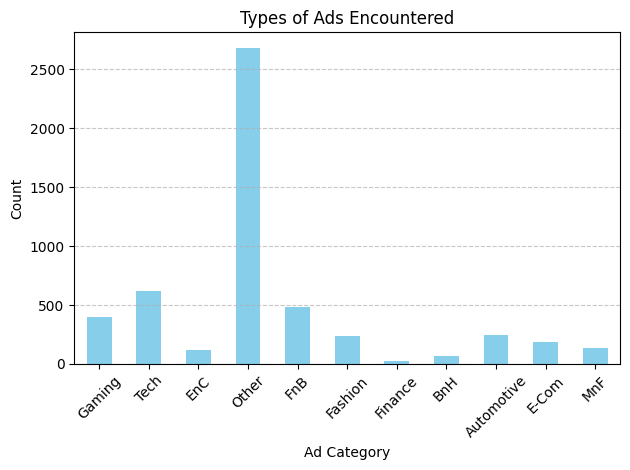

,Category,Count
3,Other,2679
1,Tech,623
4,FnB,487
0,Gaming,395
8,Automotive,245
5,Fashion,241
9,E-Com,189
10,MnF,133
2,EnC,116
7,BnH,68


In [ ]:
ads_data = []
for entry in data:
    if any(detail.get("name") == "From Google Ads" for detail in entry.get("details", [])):
        ads_data.append(entry.get("title", "No Title"))

def categorize_ad(title):
    categories = {
        "Fashion": ["fashion", "stylist", "clothing", "choreography", "beauty", "busana", "pakaian", "trend", "mode", "styling", "aksesoris", "sepatu", "tas", "outfit", "brand", "gaya", "wangi", "tahan"],
        "FnB": ["food", "drink", "cafe", "restaurant", "coffee", "tea", "mcd", "lezat", "hemat", "aqua", "kapal api", "rasakan", "taste", "maxicorn", "kuliner", "makanan", "minuman", "warung", "restoran", "kopi", "susu", "cokelat", "jajan", "es teh", "menu", "diskon", "promo"],
        "Gaming": ["game", "gaming", "valorant", "free fire", "mobile legends", "mlbb", "ff", "anime", "permainan", "bermain", "esports", "turnamen", "kompetisi", "karakter", "petualangan", "aksi", "pahlawan", "pertempuran", "game online", "game pc", "game konsol", "perangkat gaming", "controller", "permainan video", "gameplay", "fps", "rpg", "moba", "survival", "battle royale"],
        "Tech": ["tech", "gadget", "phone", "electronics", "digital", "it", "industri", "cloud", "data analytics", "5g", "pro", "series", "twitter", "facebook", "threads", "brand", "AI", "tool", "domain", "project"],
        "BnH": ["beauty", "skincare", "makeup", "health", "body", "insecure", "olahraga", "glow", "glowing", "wajah", "kusam", "hair", "supplement", "rambut", "fit", "fresh", "jerawat", "tidur", "cantik"],
        "E-Com": ["shopee", "tokopedia", "blibli", "promo", "discount", "diskon", "bukalapak", "paid", "tiktok", "ongkir", "gratis", "transaksi", "gojek", "gocar", "grabfood", "check out", "checkout", "cashback", "hemat", "belanja"],
        "Finance": ["finance", "bank", "insurance", "octafx", "asuransi", "business", "tabungan", "investasi", "emas", "saham", "reksadana", "pinjaman", "cicilan", "angsuran", "KTA", "asuransi", "proteksi", "perlindungan", "polis", "rekening", "transfer", "modal"],
        "Automotive": ["car", "motor", "auto", "drive", "castrol", "mobil", "flights", "penerbangan", "liburan", "kendaraan", "otomotif", "transportasi", "sedan", "SUV", "MPV", "mobil listrik", "electric car", "car rental", "sewa mobil", "sepeda motor", "moge", "motor listrik", "suku cadang", "oli", "ban", "perawatan", "servis", "spare parts", "maintenance", "oil", "tire", "mengemudi", "perjalanan", "driver", "penumpang", "road", "ride", "wisata", "jalan-jalan", "travel", "vacation", "holiday", "road trip"],
        "EnC": ["learn", "career", "job", "education", "school", "grammarly", "goal", "bahasa", "sekolah", "karir", "pekerjaan", "hitung", "pecahan", "peluang", "belajar", "pendidikan", "kuliah", "universitas", "sekolah", "kursus", "training", "pelatihan", "lowongan", "profesi", "magang", "bekerja", "alumni"],
        "MnF": ["guitar", "music", "ukulele", "piano", "film", "trailer", "sound", "sounds", "musik", "lagu", "konser", "penyanyi", "album", "musik video", "artis", "film", "bioskop", "tayangan", "serial", "drama", "perdana", "trailer", "sutradara", "aktor", "aktris"],
        "Other": []
    }
    for category, keywords in categories.items():
        if any(keyword in title.lower() for keyword in keywords):
            return category
    return "Other"

ad_categories = [categorize_ad(ad) for ad in ads_data]
ad_counter = Counter(ad_categories)

ad_df = pd.DataFrame(ad_counter.items(), columns=["Category", "Count"])

plt.figure(figsize=(10, 6))
ad_df.set_index("Category").plot(kind="bar", color="skyblue", legend=False)
plt.title("Types of Ads Encountered")
plt.xlabel("Ad Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

ad_df.sort_values(by="Count", ascending=False)

---

##### Filter Video from Ads

In [ ]:
filtered_data = []
for entry in data:
    if not any(detail.get("name") == "From Google Ads" for detail in entry.get("details", [])):
        filtered_data.append(entry)

filtered_file_path = 'filtered_watch_history.json'
with open(filtered_file_path, 'w', encoding='utf-8') as file:
    json.dump(filtered_data, file, ensure_ascii=False, indent=2)

In [ ]:
file_path = 'filtered_watch_history.json'
with open(file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

records = []
for entry in data:
    if 'header' in entry and entry['header'] == 'YouTube':
        time_str = entry.get('time')
        title = entry.get('title', 'No Title')
        timestamp = datetime.fromisoformat(time_str.replace('Z', '+00:00'))
        records.append({'title': title, 'timestamp': timestamp})

df = pd.DataFrame(records)

---

#### Peak Viewing Hours in Total

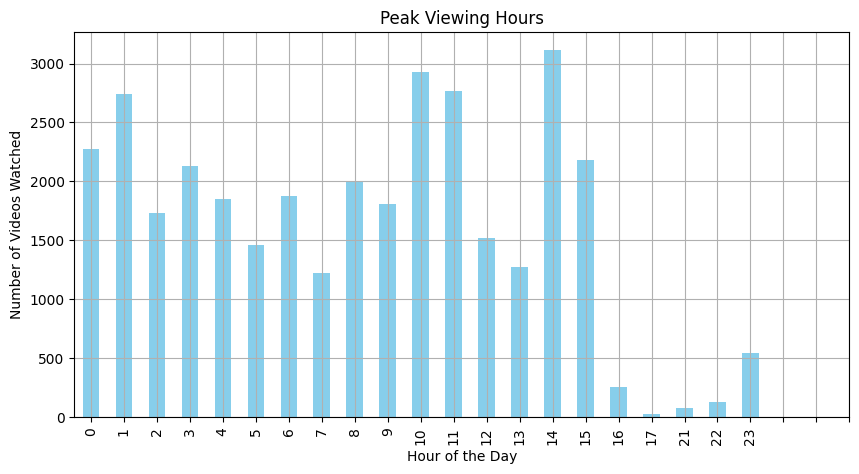

In [ ]:
df['hour'] = df['timestamp'].dt.hour

plt.figure(figsize=(10, 5))
df['hour'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Videos Watched')
plt.title('Peak Viewing Hours')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

#### Peak Viewing Hours in Average

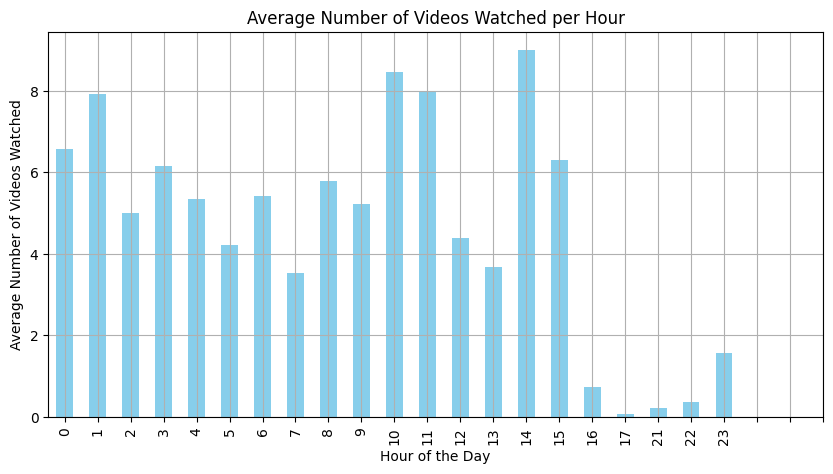

hour
0     6.575145
1     7.933526
2     4.991329
3     6.167630
4     5.335260
5     4.210983
6     5.410405
7     3.531792
8     5.797688
9     5.231214
10    8.462428
11    7.991329
12    4.398844
13    3.670520
14    8.994220
15    6.291908
16    0.745665
17    0.080925
21    0.208092
22    0.367052
23    1.566474
dtype: float64


In [ ]:
df['hour'] = df['timestamp'].dt.hour

hourly_video_counts = df.groupby('hour').size()

avg_hourly_videos = hourly_video_counts / df['timestamp'].dt.date.nunique()

plt.figure(figsize=(10, 5))
avg_hourly_videos.sort_index().plot(kind='bar', color='skyblue')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Number of Videos Watched')
plt.title('Average Number of Videos Watched per Hour')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

print(avg_hourly_videos)

---

#### Viewing Patterns by Day of the Week


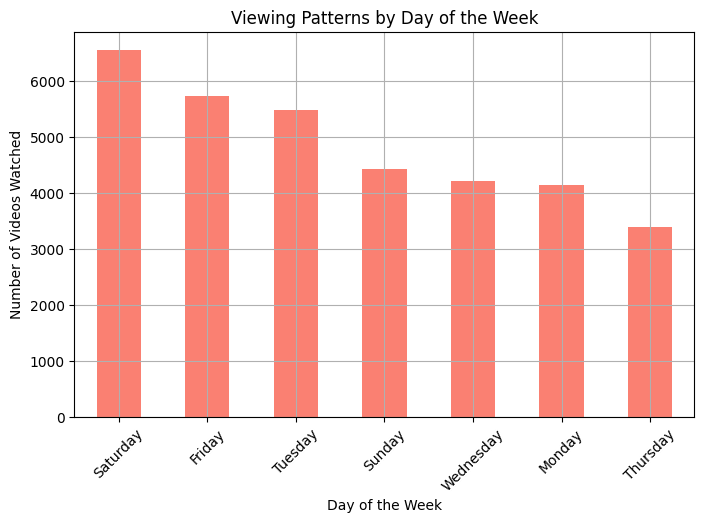

In [ ]:
df['day_of_week'] = df['timestamp'].dt.day_name()

plt.figure(figsize=(8, 5))
df['day_of_week'].value_counts().plot(kind='bar', color='salmon')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Videos Watched')
plt.title('Viewing Patterns by Day of the Week')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

#### Viewing Patterns by Day of the Week in Average


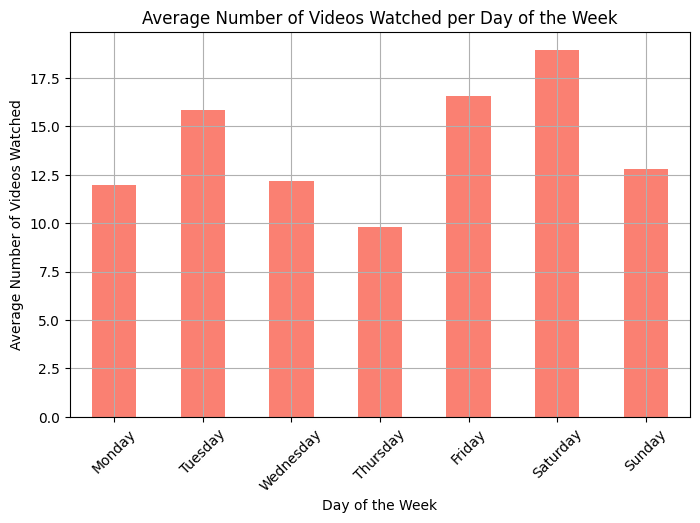

day_of_week
Monday       11.959538
Tuesday      15.812139
Wednesday    12.150289
Thursday      9.786127
Friday       16.563584
Saturday     18.919075
Sunday       12.771676
dtype: float64


In [ ]:
df['day_of_week'] = df['timestamp'].dt.day_name()

daily_video_counts = df.groupby('day_of_week').size()

avg_daily_videos = daily_video_counts / df['timestamp'].dt.date.nunique()

ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_daily_videos = avg_daily_videos[ordered_days]

plt.figure(figsize=(8, 5))
avg_daily_videos.plot(kind='bar', color='salmon')
plt.xlabel('Day of the Week')
plt.ylabel('Average Number of Videos Watched')
plt.title('Average Number of Videos Watched per Day of the Week')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

print(avg_daily_videos)

---

#### Youtube Shorts vs Long Videos

In [ ]:
records = []
for entry in data:
    if 'header' in entry and entry['header'] == 'YouTube':
        time_str = entry.get('time')
        title = entry.get('title', 'No Title')
        timestamp = datetime.fromisoformat(time_str.replace('Z', '+00:00'))
        records.append({'title': title, 'timestamp': timestamp})

df = pd.DataFrame(records)

total_videos_watched = df.shape[0]

shorts_filter = df['title'].str.contains(r'#shorts|shorts', case=False, na=False)

total_shorts_watched = df[shorts_filter].shape[0]

print(f"Total number of videos watched: {total_videos_watched}")
print(f"Total number of Long videos watched: {total_videos_watched - total_shorts_watched}")
print(f"Total number of YouTube Shorts watched: {total_shorts_watched}")


Total number of videos watched: 33895
Total number of Long videos watched: 24824
Total number of YouTube Shorts watched: 9071


---

#### Categorizing Type of Watched Videos

<Figure size 1000x600 with 0 Axes>

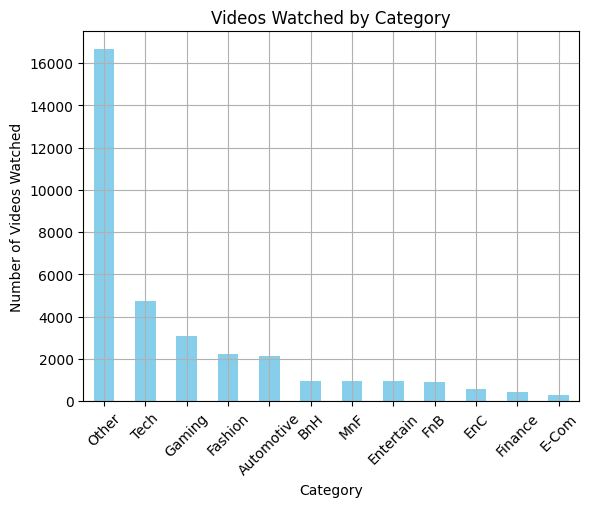

      Category  Video Count
4        Other        16665
5         Tech         4751
1       Gaming         3089
10     Fashion         2245
7   Automotive         2150
0          BnH          966
6          MnF          944
3    Entertain          939
2          FnB          882
9          EnC          570
11     Finance          404
8        E-Com          290


In [ ]:
from collections import defaultdict

categories = {
    "Fashion": [
        "fashion", "stylist", "clothing", "choreography", "beauty", "busana", "pakaian", "trend", "mode", "styling",
        "aksesoris", "sepatu", "tas", "outfit", "brand", "gaya", "wangi", "tahan", "apparel", "hairstyle", "makeup",
        "fashionista", "hairstylist", "couture", "runway", "designer", "high fashion", "streetwear", "vintage", "elegant",
        "casual wear", "luxury", "seamstress", "tailor", "fabrics", "accessories", "wear", "cosmetics", "dress", "garment",
        "moda", "t-shirt", "jeans", "shirt", "jacket", "cardigan", "scarf", "hat", "shoes", "boots", "sneakers", "suits",
        "evening wear", "formal", "wedding", "bridal", "color palette", "fabric", "pattern", "texture", "layering", "footwear",
        "couture", "embroidered", "chic", "minimalism", "sportswear", "athleisure", "street style", "street fashion",
        "fashion trends", "wardrobe", "couture", "fashion collection", "color blocking", "fashion accessories", "luxury brands",
        "sustainable fashion", "eco fashion", "sustainable fabrics", "slow fashion", "ethical fashion", "brand", "vintage style",
        "styling tips", "style inspiration", "catwalk", "vintage trends", "fashion haul", "fashion blog", "personal stylist",
        "tailored", "urban wear", "couture dress", "fashion show", "minimalistic", "bold fashion", "stylist tips", "fashionista",
        "outfit inspiration", "hair care", "beauty", "cosmetic", "mannequin", "lookbook", "accessory", "couture fashion",
        "makeup artist", "street style", "fashion design", "men's fashion", "women's fashion", "fashion forward", "trendy",
        "contemporary fashion", "fashion forward", "preppy style", "boho chic", "fashion collaboration"
    ],

    "FnB": [
        "food", "drink", "cafe", "restaurant", "coffee", "tea", "mcd", "lezat", "hemat", "aqua", "kapal api", "rasakan",
        "taste", "maxicorn", "kuliner", "makanan", "minuman", "warung", "restoran", "kopi", "susu", "cokelat", "jajan",
        "es teh", "menu", "diskon", "promo", "meals", "dessert", "snack", "soup", "fruits", "vegetables", "meat", "chicken",
        "pizza", "pasta", "burger", "hotdog", "steak", "spaghetti", "sushi", "pancakes", "waffles", "cake", "donuts",
        "biscuits", "cookies", "ice cream", "juices", "smoothies", "baking", "fast food", "fine dining", "delicious",
        "restaurant review", "food vlog", "street food", "cuisine", "menu specials", "tasting", "breakfast", "lunch",
        "dinner", "beverages", "cocktail", "mocktail", "drink recipes", "barista", "espresso", "latte", "milkshake", "mocha",
        "foodie", "gastronomy", "gastronomy blog", "ingredients", "recipe", "cookbook", "international cuisine", "italian food",
        "indian food", "asian cuisine", "mediterranean", "chinese food", "mexican food", "vegetarian", "vegan", "food blogs",
        "food photography", "food review", "restaurant tour", "cooking tutorial", "homemade", "quick recipes", "healthy food",
        "gourmet", "taste testing", "food challenges", "delight", "tapas", "picnic", "meal prep", "dining", "banquet",
        "buffet", "food stalls", "gastro", "breweries", "cooking hacks", "home cooking", "sizzling", "fermented foods",
        "boba tea", "sandwich", "smoothie bowls", "noodles", "tacos", "hot pot", "coffee brewing", "kombucha", "barbecue",
        "sweets", "crisps", "french fries", "popcorn", "water", "gluten-free", "sugar-free", "organic food", "dietary supplements"
    ],

    "Gaming": [
        "game", "gaming", "valorant", "free fire", "mobile legends", "mlbb", "ff", "anime", "permainan", "bermain", "esports",
        "turnamen", "kompetisi", "karakter", "petualangan", "aksi", "pahlawan", "pertempuran", "game online", "game pc",
        "game konsol", "perangkat gaming", "controller", "permainan video", "gameplay", "fps", "rpg", "moba", "survival",
        "battle royale", "strategy", "simulation", "action", "adventure", "role-playing", "multiplayer", "singleplayer",
        "pc gaming", "console", "xbox", "playstation", "nintendo", "gaming setup", "gaming chair", "streaming", "twitch",
        "youtube gaming", "gaming events", "video game culture", "gaming community", "gamer", "online multiplayer", "gamer tags",
        "game controller", "virtual reality", "augmented reality", "battle royale games", "esports tournaments", "esports league",
        "competitive gaming", "gamer squad", "leaderboard", "new releases", "upcoming games", "game dev", "game developers",
        "game trailer", "gaming news", "e-sports news", "gaming console", "gaming review", "first-person shooter", "third-person",
        "fighting games", "racing games", "sports games", "strategy games", "action adventure", "open world games", "sandbox",
        "narrative-driven games", "survival horror", "survival games", "battle pass", "in-game items", "skins", "loot", "multiplayer",
        "indie games", "free-to-play", "pay-to-play", "game update", "patch", "beta testing", "video game streaming", "modding",
        "video game graphics", "game music", "game soundtracks", "tournaments", "video game industry", "PC build", "gaming PC",
        "graphics card", "game mods", "hero", "alok", "amw", "mp-40", "smg", "magic chess", "giveaway", "diamond", "sultan", "bocil", "epic games", "playstation 5", "xbox series x", "playstation 4", "old games", "retro gaming",
        "arcade games", "multiplayer modes", "co-op games", "party games", "mobile games", "mobile gaming", "game cheats", "game hacks",
        "mobile legends bang bang", "mlbb heroes", "headshot", "kill", "k1ll", "mati", "m4ti", "mobile legends skin", "ranked mobile legends", "mobile legends tournament", "mlbb squad", "mobile legends tips", "mobile legends strategy",
        "mobile legends guide", "review skin", "ez", "mlbb build", "mlbb gameplay", "mobile legends pro player", "mobile legends team", "free fire", "free fire gameplay", "ff characters", "free fire skins",
        "free fire tips", "free fire top up", "ff rank", "free fire tournament", "free fire pro player", "free fire battle royale", "free fire gameplay tips", "free fire strategy",
        "free fire skins", "ff diamond", "free fire new update", "free fire weapons", "ff team", "ff events", "mobile legends clash of titans", "mobile legends event", "mlbb patch notes",
        "mobile legends heroes list", "mobile legends hero tier list", "mobile legends skins sale", "free fire pet", "ff character abilities", "mobile legends item build", "mobile legends patch",
        "free fire ranked", "free fire 4v4", "free fire squad", "free fire team fight", "free fire solo", "mobile legends e-sport", "mobile legends hero skins", "mobile legends customization",
        "mobile legends pro league", "mobile legends grandmaster", "mlbb push rank", "free fire competitive", "mobile legends new hero", "free fire advance server", "mlbb legendary",
        "free fire gameplay mechanics", "mobile legends player vs player", "mobile legends gameplay modes", "mobile legends and free fire comparison", "free fire high ground", "ff strategies",
        "mobile legends tournament updates", "free fire clan war", "mobile legends buff", "mobile legends nerf", "mobile legends meta", "ff gameplay mechanics", "free fire pro tips",
        "mobile legends win rate", "ff community", "mobile legends best heroes", "free fire tips for beginners", "mlbb ultimate", "ff victory royale", "mobile legends hero mastery",
        "free fire skills", "free fire headshots", "mlbb rank system", "free fire battle pass", "mlbb professional tournaments", "mobile legends guild", "free fire esports"
    ],

    "Tech": [
        "tech", "gadget", "phone", "electronics", "digital", "it", "industri", "cloud", "data analytics", "5g", "pro", "series",
        "twitter", "facebook", "threads", "brand", "AI", "tool", "domain", "project", "hp", "inovasi", "laptop", "tv", "gadget",
        "startup", "innovation", "artificial intelligence", "machine learning", "blockchain", "virtual reality", "augmented reality",
        "cybersecurity", "iot", "internet of things", "networking", "smart home", "cloud storage", "data protection", "robotics",
        "smartphones", "wearables", "smartwatches", "fitness trackers", "apps", "mobile apps", "software", "digital marketing",
        "website development", "programming", "coding", "python", "java", "html", "css", "javascript", "web apps", "data science",
        "big data", "cloud computing", "database", "tech startup", "tech conference", "tech news", "tech trends", "future tech",
        "mobile development", "app development", "devops", "design", "ux", "ui", "analytics", "databases", "data mining", "algorithms",
        "deep learning", "google", "microsoft", "amazon", "apple", "samsung", "android", "ios", "internet", "web", "cloud services",
        "machine vision", "machine perception", "AI assistants", "voice recognition", "computer vision", "chatbot", "automation",
        "smart tech", "e-commerce", "digital wallet", "fintech", "e-business", "IT support", "productivity tools", "video conferencing",
        "zoom", "microsoft teams", "web security", "digital transformation", "wireless", "fiber optics", "5G network", "edge computing",
        "tech tutorials", "technology blog", "future trends", "software engineer", "app developer", "tech career", "high-tech", "AR",
        "VR", "augmented reality", "3d printing", "coding bootcamp", "database management", "enterprise tech", "cloud security",
        "AI chatbot", "cloud applications", "digital transformation", "tech stack", "startup culture", "mobile technology", "social media"
    ],

    "BnH": [
        "beauty", "skincare", "makeup", "health", "body", "insecure", "olahraga", "glow", "glowing", "wajah", "kusam", "hair", "supplement", "rambut", "fit", "fresh", "jerawat", "tidur", "cantik", "Piala dunia", "pildun", "bola", "dribble", "shot", "shooting", "tendangan", "FIFA", "pemain", "pelatih",
        "acne", "anti-aging", "hyaluronic acid", "selebrasi", "serum", "moisturizer", "collagen", "vitamin C", "face mask", "facial", "anti-wrinkle", "spa", "massage", "haircare", "nail polish", "manicure", "pedicure", "lipstick", "foundation", "eyeshadow", "blush", "perfume", "hair color", "laser treatment", "sunblock", "sunscreen", "anti-acne", "shampoo", "hair straightener", "makeup artist", "beautician", "detox", "wellness", "mental health", "stress", "meditation", "yoga", "fitness", "healthy diet", "weight loss", "exercise", "workout", "gym", "healthy food", "herbal", "organic", "natural beauty", "vitamins", "minerals", "omega-3", "protein", "supplementation", "weight gain", "dieting", "body care", "personal hygiene", "skin rejuvenation", "natural hair", "dandruff", "hair loss", "strengthening", "hydration", "skin type", "body shaping", "stretch marks", "skin blemishes", "detox tea", "green tea", "aromatherapy", "organic cosmetics", "lip balm", "face cream", "hair growth", "collagen peptides", "gut health", "gut flora", "metabolism", "body fat", "calories", "blood pressure", "exercise routine", "wellness blog", "gluten-free", "cleanse", "clean beauty", "indoor plants", "anti-inflammatory", "cardio", "strength training", "weight training", "plank", "yoga poses", "stretching", "chiropractic", "massage therapy", "spa day", "body scrub", "natural skincare", "exfoliation", "detoxifying foods", "caffeine", "pre-workout", "post-workout recovery", "workout clothing", "fitness tracker", "sleep routine", "rest day", "nutritionist", "home gym", "protein shakes", "fat burners", "detox bath", "acupuncture", "naturopathy", "wellness retreat", "healthy lifestyle", "activewear", "low-carb", "keto", "paleo", "intermittent fasting", "hydration booster", "holistic wellness", "skin protection", "hormonal balance", "gut microbiome", "essential oils", "muscle recovery", "aromatherapy diffuser", "teeth whitening", "face wash", "skin tone", "blemish-free", "smooth skin", "detox water", "superfoods", "organic food", "biohacking", "mental clarity", "calming", "brain health"
    ],

    "E-Com": [
        "shopee", "tokopedia", "blibli", "promo", "discount", "diskon", "bukalapak", "paid", "tiktok", "ongkir", "gratis", "transaksi", "gojek", "gocar", "grabfood", "check out", "checkout", "cashback", "hemat", "belanja",
        "shopping", "shopping cart", "checkout", "online store", "fashion", "electronics", "gadgets", "digital products", "home appliances", "accessories", "gift cards", "e-gift", "mobile phones", "laptops", "headphones", "smartwatches", "TV", "kitchenware", "furniture", "beauty products", "makeup", "cosmetics", "skincare", "healthcare", "fitness equipment", "sports goods", "toys", "books", "grocery delivery", "home decor", "ecommerce marketing", "dropshipping", "retail", "product page", "marketplace", "B2B", "B2C", "direct to consumer", "product reviews", "user-generated content", "SEO", "search engine optimization", "affiliate marketing", "referral program", "social media marketing", "Instagram shopping", "Facebook ads", "Google ads", "influencer marketing", "content creator", "influencers", "price comparison", "payment gateway", "Stripe", "PayPal", "credit card payment", "e-wallet", "secure checkout", "payment methods", "international shipping", "local delivery", "parcel tracking", "order confirmation", "invoice", "returns", "refund policy", "exchange policy", "free shipping", "flash sale", "limited-time offer", "seasonal sale", "loyalty program", "coupon", "promo code", "voucher", "gifts", "freebies", "bundle offers", "buy one get one", "free delivery", "on-demand delivery", "order tracking", "instore pickup", "shopping app", "discount codes", "exclusive deal", "membership benefits", "subscription", "recurrent payments", "bulk buying", "wholesale", "ecommerce analytics", "order fulfillment", "drop shipping", "ecommerce platform", "Amazon", "Shopify", "WooCommerce", "Magento", "Etsy", "marketplace trends", "product launch", "shopping cart abandonment", "conversion rate", "UX/UI design", "website optimization", "retargeting", "remarketing", "click-through rate", "customer retention", "checkout flow", "mobile payment", "QR code payment", "buy now pay later", "payment security", "fraud prevention", "order confirmation email", "product wishlist", "checkout page design", "payment processing", "shopping experience", "AI chatbot", "customer service", "order history", "special offers", "in-app purchases", "online auction", "re-commerce", "refurbished products", "eco-friendly products", "used goods", "second-hand marketplace", "direct sales", "customer support", "live chat support", "returns policy", "product packaging", "bulk order", "product information", "chatbots", "personalization", "cross-selling", "up-selling", "catalog management", "merchant account", "global shipping", "customer feedback", "buyer's guide", "ecommerce statistics", "advertising spend", "Google Shopping", "price comparison site", "Amazon Prime", "Snapchat ads", "TikTok ads", "Pinterest marketing", "consumer behavior", "mobile commerce", "m-commerce"
    ],

    "Finance": [
        "finance", "bank", "insurance", "octafx", "asuransi", "business", "tabungan", "investasi", "emas", "saham", "reksadana", "pinjaman", "cicilan", "angsuran", "KTA", "asuransi", "proteksi", "perlindungan", "polis", "rekening", "transfer", "modal", "IPO", "pensiun",
        "stocks", "mutual funds", "debt", "sukses", "kaya", "saham", "perusahaan", "equities", "dividends", "brokerage", "share market", "financial planning", "wealth management", "asset management", "personal finance", "budgeting", "savings", "debt management", "retirement savings", "401k", "taxes", "loans", "mortgage", "real estate", "property investment", "insurance policy", "financial advisor", "credit score", "credit card", "financial literacy", "cryptocurrency", "bitcoin", "blockchain", "altcoins", "Ethereum", "NFT", "tokenomics", "decentralized finance", "stocks analysis", "investment strategies", "stock trading", "Forex", "currency exchange", "commodities", "gold investment", "silver investment", "trading platforms", "stock market news", "financial risk", "portfolio management", "rebalancing", "stock analysis", "day trading", "buy and hold", "dividend yield", "capital gains", "asset allocation", "index funds", "ETFs", "financial statement", "income statement", "balance sheet", "cash flow", "investor relations", "earnings report", "venture capital", "angel investors", "crowdfunding", "private equity", "business loan", "startup funding", "financial crisis", "economic growth", "inflation", "interest rate", "Federal Reserve", "ECB", "debt-to-income ratio", "loan amortization", "credit history", "bankruptcy", "financial market", "fundamental analysis", "technical analysis", "stock pickers", "economic indicators", "GDP", "consumer price index", "global economy", "investment banking", "credit union", "financial products", "risk management", "hedging", "insurance premiums", "mortgage rates", "loan terms", "interest rate swap", "recession", "economic recession", "financial collapse", "interest rates hike", "central bank", "hedge fund", "corporate finance", "public finance", "cost-benefit analysis", "inflationary pressure", "fiscal policy", "monetary policy", "budget deficit", "balance of trade", "trade deficit", "stock portfolio", "retirement plan", "pension fund", "capital market", "commodity trading", "foreign direct investment", "municipal bonds", "credit default swap", "syndicated loan", "equity crowdfunding", "debt securities", "treasury bonds", "real estate investment trust", "REIT", "inflation hedge", "currency risk", "venture capitalist", "angel funding", "fiscal stimulus", "financial products", "market cap", "M1 money supply", "capital structure", "company valuation", "economic cycle", "financial crisis"
    ],

    "Automotive": [
      "how", "car", "motor", "auto", "drive", "castrol", "mobil", "flights", "penerbangan", "liburan", "kendaraan", "otomotif", "transportasi", "sedan", "SUV", "MPV", "mobil listrik",
      "electric car", "car rental", "sewa mobil", "sepeda motor", "moge", "motor listrik", "suku cadang", "oli", "ban", "perawatan", "servis", "spare parts", "maintenance", "oil",
      "tire", "mengemudi", "perjalanan", "driver", "penumpang", "road", "ride", "wisata", "jalan-jalan", "travel", "vacation", "holiday", "road trip", "automobile", "vehicle", "engine",
      "transmission", "brake", "clutch", "tire pressure", "electric vehicle", "battery", "tesla", "car charging", "hybrid car", "car review", "car test", "car comparison", "sedan review",
      "SUV review", "MPV review", "luxury car", "sports car", "sedan", "roadster", "convertible", "car maintenance tips", "eco-friendly car", "reliable car", "car insurance", "car dealership",
      "car sale", "vehicle safety", "crash test", "autonomous vehicle", "self-driving car", "robotaxi", "vehicle tracking", "car accessories", "car gadget", "automobile repair", "mechanic",
      "oil change", "engine oil", "car diagnostics", "car repairs", "vehicle servicing", "4x4", "off-road", "car camping", "road trip essentials", "car care", "auto detailing", "car washing",
      "car interior cleaning", "car safety features", "car insurance claim", "car loan", "leasing car", "motorcycle", "bike", "scooter", "moped", "motorbike repair", "motorbike racing",
      "motorbike review", "motorcycle accessories", "motorcycle safety", "motorcycle rental", "motorcycle gear", "motorcycle helmet", "motorcycle jacket", "bike repair", "bike test", "vehicle modification"
    ],

    "EnC": [
        "learn", "career", "job", "education", "school", "grammarly", "goal", "bahasa", "sekolah", "karir", "pekerjaan", "hitung", "pecahan", "peluang", "belajar", "pendidikan", "kuliah",
        "universitas", "sekolah", "kursus", "training", "pelatihan", "lowongan", "profesi", "magang", "bekerja", "alumni", "soal", "matematika", "ielts", "toefl", "online learning",
        "skill development", "certification", "course", "study guide", "job search", "resume", "career advice", "internship", "professional growth", "career path", "work experience",
        "networking", "job interview", "freelancing", "gig economy", "remote work", "part-time job", "full-time job", "career development", "graduate school", "entrepreneurship", "startup",
        "business owner", "small business", "job market", "career opportunities", "salary negotiation", "workplace culture", "corporate world", "leadership", "management skills", "project management",
        "business strategy", "economics", "job trends", "working from home", "college", "university degrees", "higher education", "professional skills", "student loans", "scholarships",
        "degree programs", "career coach", "self-improvement", "job placement", "job market trends", "leadership training", "personal development", "teamwork", "communication skills",
        "self-employment", "public speaking", "time management", "critical thinking", "problem solving", "conflict resolution", "creative thinking", "decision making", "work-life balance",
        "productivity", "team collaboration", "career switch", "job satisfaction", "work motivation", "career counseling", "coaching", "personal branding", "job promotion", "salary survey",
        "professional networking", "e-learning", "tutorial", "coursework", "workshops", "conference", "seminars", "education system", "teaching", "curriculum development", "academic research",
        "distance learning", "career fair", "resume tips", "LinkedIn profile", "job board", "job posting", "employment agency", "job application", "career growth", "job training"
    ],

    "MnF": [
        "guitar", "music", "ukulele", "piano", "film", "trailer", "sound", "sounds", "musik", "lagu", "konser", "penyanyi", "album", "musik video", "artis", "film", "bioskop", "tayangan",
        "serial", "drama", "perdana", "trailer", "sutradara", "aktor", "aktris", "drum", "alur", "drummers", "kit", "guitarist", "relaxing", "instrumental", "groove", "music producer",
        "indie music", "jazz", "rock", "pop", "classical", "hip-hop", "rap", "electronic", "blues", "singer-songwriter", "musician", "band", "album release", "music streaming",
        "Spotify", "Apple Music", "iTunes", "YouTube music", "concert", "gig", "soundtrack", "film score", "movie soundtrack", "director", "film industry", "cinema", "movie review",
        "film festival", "blockbuster", "indie film", "documentary", "short film", "feature film", "movie trailer", "cinematography", "actors", "movie scene", "screenplay", "movie director",
        "script writing", "film production", "set design", "filmmaking", "movie plot", "cinema lovers", "film script", "movie analysis", "film critique", "film acting", "actors in movies",
        "casting call", "audition", "red carpet", "award ceremony", "film editing", "post-production", "film industry trends", "box office", "theater", "movie theater", "film budget",
        "movie genre", "comedy", "horror", "action", "drama", "romance", "documentary", "sci-fi", "fantasy", "musical", "animated film", "CGI", "special effects", "film awards", "film reviews",
        "acting tips", "singing lessons", "dance choreography", "musical theater", "sound engineer", "audio production", "live performance", "music festival", "acoustic guitar",
        "drum kit", "DJ", "musical instruments", "cover songs", "music composition", "sound mixing", "film sound design", "mixing engineer", "music arrangement", "choir", "opera",
        "orchestra", "voice training", "song lyrics", "beatmaking", "music beats", "melody", "harmony", "music theory", "composer", "music production software", "songwriting", "guitar tutorial"
    ],

    "Entertain": [
        "podcast", "podcasts", "comedy", "funny", "humor", "laugh", "joke", "stand-up", "improv",
        "celebrity", "actors", "actress", "musician", "singer", "song", "album", "concert", "band",
        "music video", "red carpet", "hollywood", "showbiz", "indie music", "movie", "film",
        "blockbuster", "cinema", "movie review", "director", "producer", "acting", "casting",
        "television", "TV show", "reality TV", "game show", "reality", "television host",
        "TV personality", "series", "soap opera", "drama", "romance", "action movie", "thriller",
        "horror movie", "adventure", "musical", "romantic comedy", "talk show", "late night show",
        "award show", "Oscars", "Grammy", "MTV", "Emmy", "BAFTA", "Golden Globe", "festival",
        "fashion", "beauty", "model", "lifestyle", "celebrity gossip", "Hollywood stars", "film festival",
        "music industry", "entertainment news", "pop culture", "viral", "trending", "viral videos",
        "celebrity news", "interview", "exclusive", "press release", "behind the scenes", "famous",
        "superstar", "talent", "event", "red carpet event", "paparazzi", "pop music", "hip hop",
        "rock music", "rap", "indie", "pop star", "music awards", "album release", "dance",
        "dance video", "TikTok", "YouTube star", "vlog", "vlogger", "influencer", "livestream",
        "streaming", "Netflix", "Hulu", "Disney+", "Prime Video", "YouTube Originals", "series finale",
        "television special", "behind the scenes", "MTV Video Music Awards", "Billboard",
        "K-pop", "BTS", "BLACKPINK", "GOT7", "EXO", "TWICE", "Red Velvet", "IU", "J-Hope", "GDragon",
        "NCT", "selebriti Indonesia", "Bunga Citra Lestari", "Raisa", "Ariel NOAH", "Tulus",
        "Anggun", "Iwan Fals", "Agnez Mo", "Celine Dion", "Deddy Corbuzier", "Raffi Ahmad", "Nagita Slavina",
        "Luna Maya", "Sarah Sechan", "Jessica Iskandar", "Gading Marten", "Nadine Chandrawinata",
        "Yuni Shara", "BCL", "Rizky Febian", "Shawn Mendes", "Zayn Malik", "Selena Gomez", "Justin Bieber",
        "Ariana Grande", "Taylor Swift", "Ed Sheeran", "Katy Perry", "Adele", "Billie Eilish",
        "Miley Cyrus", "Lady Gaga", "Kylie Jenner", "Kim Kardashian", "Khloe Kardashian", "Kendall Jenner",
        "Kourtney Kardashian", "Emma Watson", "Tom Hanks", "Will Smith", "Keanu Reeves", "Johnny Depp",
        "Scarlett Johansson", "Chris Hemsworth", "Zendaya", "Emma Stone", "Ryan Gosling", "Chris Evans",
        "Robert Downey Jr.", "Jennifer Lawrence", "Brad Pitt", "Angelina Jolie", "Tom Cruise", "Dwayne Johnson",
        "Mark Ruffalo", "Scarlett Johansson", "Avengers", "Marvel", "DC Comics", "Superman", "Batman",
        "Iron Man", "Spider-Man", "Wonder Woman", "Thor", "Captain America", "Black Panther", "Hunger Games",
        "Twilight", "Harry Potter", "The Witcher", "Game of Thrones", "Stranger Things", "Friends",
        "Breaking Bad", "The Office", "The Crown", "Big Bang Theory", "Narcos", "The Mandalorian",
        "Money Heist", "Rick and Morty", "The Simpsons", "The Walking Dead", "The Flash", "Arrow",
        "Supergirl", "Batwoman", "Gotham", "Teen Titans", "Teen Wolf", "Shameless", "Peaky Blinders",
        "Riverdale", "Lucifer", "Charmed", "The Vampire Diaries", "Grey's Anatomy", "Grey's Anatomy",
        "Chicago PD", "Black Mirror", "The Handmaid's Tale", "The Boys", "Westworld", "Big Little Lies",
        "True Detective", "Lost", "The X-Files", "Doctor Who", "Lucifer", "Friends Reunion", "Glee",
        "Will & Grace", "The Fresh Prince of Bel-Air", "All American", "Love Island", "The Bachelor",
        "America's Got Talent", "The Voice", "MasterChef", "Survivor", "Top Chef", "Big Brother",
        "Love Island", "So You Think You Can Dance", "America's Next Top Model", "The Challenge", "Dance Moms"
    ],

    "Other": []
}

category_counts = defaultdict(int)

for entry in data:
    title = entry.get('title', '').lower()
    matched_category = False
    for category, keywords in categories.items():
        if any(keyword in title for keyword in keywords):
            category_counts[category] += 1
            matched_category = True
            break

    if not matched_category:
        category_counts["Other"] += 1

category_df = pd.DataFrame(list(category_counts.items()), columns=['Category', 'Video Count'])

category_df = category_df.sort_values(by='Video Count', ascending=False)

plt.figure(figsize=(10, 6))
category_df.plot(kind='bar', x='Category', y='Video Count', legend=False, color='skyblue')
plt.xlabel('Category')
plt.ylabel('Number of Videos Watched')
plt.title('Videos Watched by Category')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

print(category_df)

# **Search History**

In [ ]:
file_path = 'search-history.json'
with open(file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

---

#### Filtering

In [ ]:
# Filter the data to keep only items where the title starts with "Searched for"
filtered_data = [entry for entry in data if entry['title'].startswith("Searched for")]

# Save the filtered data to a new JSON file
new_file_path = 'filtered-search-history.json'
with open(new_file_path, 'w', encoding='utf-8') as new_file:
    json.dump(filtered_data, new_file, ensure_ascii=False, indent=4)

In [ ]:
file_path = 'filtered-search-history.json'
with open(file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

df = pd.DataFrame(data)

---

#### Search Frequency

In [ ]:
from tabulate import tabulate

df['title'] = df['title'].str.replace('Searched for ', '', regex=False)

search_freq = df['title'].value_counts()

search_freq_df = search_freq.to_frame(name='Frequency')

print(tabulate(search_freq_df, headers=['Title', 'Frequency'], tablefmt='fancy_grid', stralign='center', numalign='center', colalign=('center', 'center')))

╒═════════════════════════════════╤═════════════╕
│              Title              │  Frequency  │
╞═════════════════════════════════╪═════════════╡
│           迎向大自然            │      4      │
├─────────────────────────────────┼─────────────┤
│          月光普照世界           │      4      │
├─────────────────────────────────┼─────────────┤
│             有点甜              │      3      │
├─────────────────────────────────┼─────────────┤
│              稻香               │      3      │
├─────────────────────────────────┼─────────────┤
│              童话               │      2      │
├─────────────────────────────────┼─────────────┤
│            印尼花香             │      2      │
├─────────────────────────────────┼─────────────┤
│              书法               │      2      │
├─────────────────────────────────┼─────────────┤
│              父亲               │      2      │
├─────────────────────────────────┼─────────────┤
│           影响大自然            │      2      │
├──────────────────────────────

#### Analyze How Often The Search

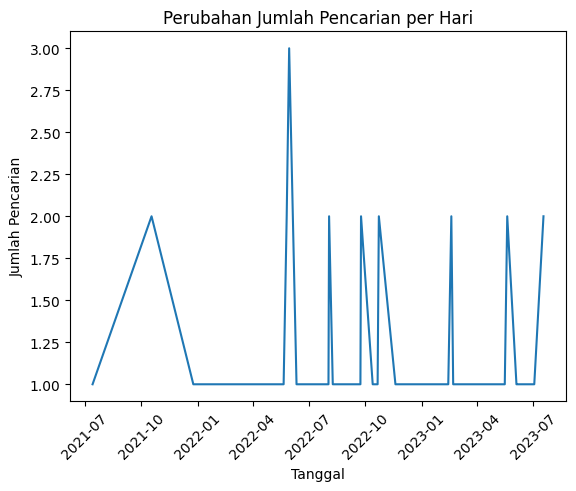

In [ ]:
df['time'] = pd.to_datetime(df['time'])

daily_searches = df.groupby(df['time'].dt.date).size()

import matplotlib.pyplot as plt
plt.plot(daily_searches.index, daily_searches.values)
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Pencarian')
plt.title('Perubahan Jumlah Pencarian per Hari')
plt.xticks(rotation=45)
plt.show()